# Module 5 — Classification (SVM)
## Automated Face Recognition Attendance System

**Branch:** `feature/classification`  
**Author:** Waad  
**Model:** Support Vector Machine (SVM) — RBF Kernel  

---
### Pipeline Position
```
Preprocessing → Face Detection → Feature Extraction (Embeddings) → ✅ Classification → Attendance
```


## 1. Import Libraries

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder, normalize

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 2. Load Face Embeddings

نحمّل الـ `.pkl` database اللي اتبنى في **Embeddings module**.  
كل subject عنده 10 embeddings بحجم 512 dimension (FaceNet-512).


In [2]:
DB_PATH = r"../outputs/database/face_embeddings.pkl"

with open(DB_PATH, "rb") as f:
    database = pickle.load(f)

print(f"✅ Loaded embedding database")
print(f"   • Total subjects  : {len(database)}")
print(f"   • Embedding dim   : {list(database.values())[0]['mean'].shape[0]}")
print(f"   • Images/subject  : {len(list(database.values())[0]['all'])}")


✅ Loaded embedding database
   • Total subjects  : 40
   • Embedding dim   : 512
   • Images/subject  : 10


## 3. Prepare Dataset (X, y)

بنستخدم **كل الـ individual embeddings** (مش بس الـ mean) عشان نبني dataset كامل.  
ده بيدينا **400 sample** (40 subject × 10 image).

الـ embeddings بتتعمل لها **L2 normalization** — مهم لاستقرار الـ SVM.


In [3]:
X, y = [], []

for subject, data in database.items():
    for emb in data["all"]:
        X.append(emb)
        y.append(subject)

X = np.array(X)
y = np.array(y)

# L2 normalization — ضرورية لاستقرار الـ SVM في الـ high-dimensional space
X_norm = normalize(X, norm="l2")

# تحويل الـ labels من string لـ integers
le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f"Dataset shape   : {X_norm.shape}")
print(f"Classes         : {len(np.unique(y))} subjects (s1 → s40)")
print(f"Total samples   : {X_norm.shape[0]}")
print(f"Feature dim     : {X_norm.shape[1]}")


Dataset shape   : (400, 512)
Classes         : 40 subjects (s1 → s40)
Total samples   : 400
Feature dim     : 512


## 4. Train / Test Split

| Set   | Ratio | Samples |
|-------|-------|---------|
| Train | 70%   | 280     |
| Test  | 30%   | 120     |

`stratify=y_enc` بتضمن إن كل class موجودة بنفس النسبة في الـ train والـ test.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Classes in train : {len(np.unique(y_train))}")
print(f"Classes in test  : {len(np.unique(y_test))}")


Training samples : 280
Testing  samples : 120
Classes in train : 40
Classes in test  : 40


## 5. Train SVM Classifier

### ليه SVM للـ Face Recognition؟
- بيعمل maximize للـ margin بين الـ classes — قوي على الـ high-dimensional data
- الـ RBF kernel بيتعامل مع الـ non-linear separation في الـ 512-D embedding space
- أثبت كفاءة عالية على datasets مشابهة للـ face recognition

### الـ Hyperparameters

| Parameter | Value  | السبب |
|-----------|--------|--------|
| `kernel`  | `rbf`  | يتعامل مع الـ non-linearity في الـ 512-D space |
| `C`       | `10`   | يسمح ببعض الـ misclassification للـ generalization |
| `gamma`   | `scale`| Auto-scaled بالنسبة لـ features و variance |


In [5]:
# ── Train ──────────────────────────────────────────────────────────────────
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train, y_train)

print("✅ SVM model trained successfully")
print(f"   kernel : {svm.kernel}")
print(f"   C      : {svm.C}")
print(f"   gamma  : {svm.gamma}")
print(f"   classes: {svm.classes_.shape[0]}")


✅ SVM model trained successfully
   kernel : rbf
   C      : 10
   gamma  : scale
   classes: 40


## 6. Evaluate on Test Set

In [6]:
# ── Predict ────────────────────────────────────────────────────────────────
y_pred = svm.predict(X_test)

# ── Metrics ────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("=" * 40)
print("     SVM Classification Results")
print("=" * 40)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)


     SVM Classification Results
  Accuracy  : 0.9667  (96.67%)
  Precision : 0.9812
  Recall    : 0.9667
  F1-Score  : 0.9656


## 7. Cross Validation (5-Fold)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm, X_norm, y_enc, cv=cv, scoring="accuracy")

print(f"CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores     : {[round(s, 4) for s in cv_scores]}")


CV Accuracy (5-fold): 0.9850 ± 0.0050
Per-fold scores     : [0.975, 0.9875, 0.9875, 0.9875, 0.9875]


## 8. Full Classification Report

In [8]:
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         3
         s10       1.00      1.00      1.00         3
         s11       1.00      1.00      1.00         3
         s12       1.00      1.00      1.00         3
         s13       1.00      1.00      1.00         3
         s14       1.00      1.00      1.00         3
         s15       1.00      1.00      1.00         3
         s16       1.00      1.00      1.00         3
         s17       1.00      1.00      1.00         3
         s18       1.00      1.00      1.00         3
         s19       1.00      1.00      1.00         3
          s2       1.00      1.00      1.00         3
         s20       1.00      1.00      1.00         3
         s21       1.00      1.00      1.00         3
         s22       1.00      1.00      1.00         3
         s23       1.00      1.00      1.00         3
         s24       1.00      1.00      1.00         3
         s25       0.75    

## 9. Visualizations

### 9.1 — Confusion Matrix

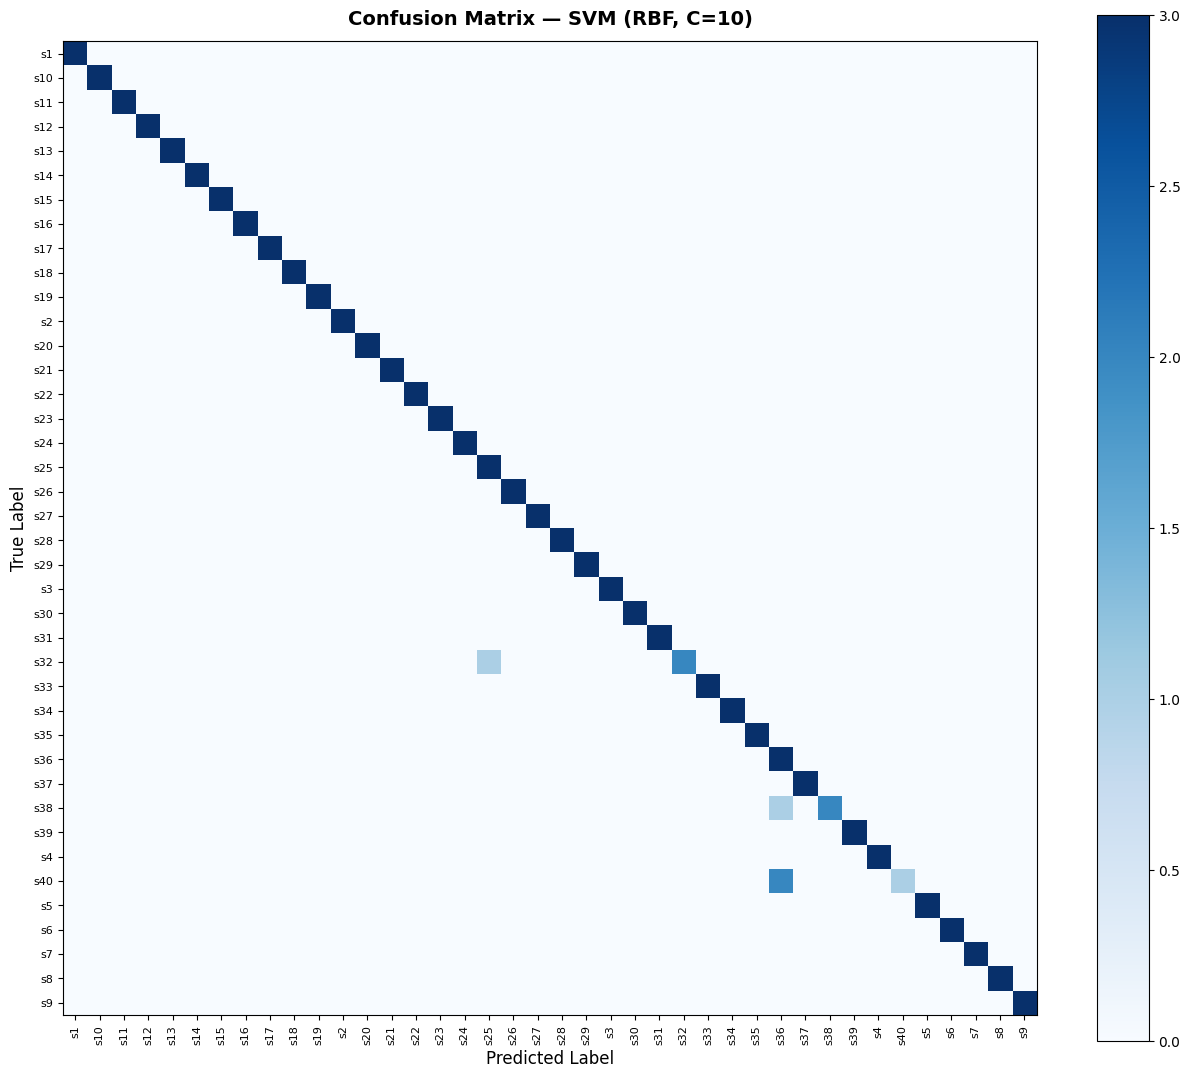

✅ Saved: svm_confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix — SVM (RBF, C=10)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

tick_marks = np.arange(len(le.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(le.classes_, rotation=90, fontsize=8)
ax.set_yticklabels(le.classes_, fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()

os.makedirs("../outputs/results", exist_ok=True)
plt.savefig("../outputs/results/svm_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: svm_confusion_matrix.png")


### 9.2 — Metrics Bar Chart

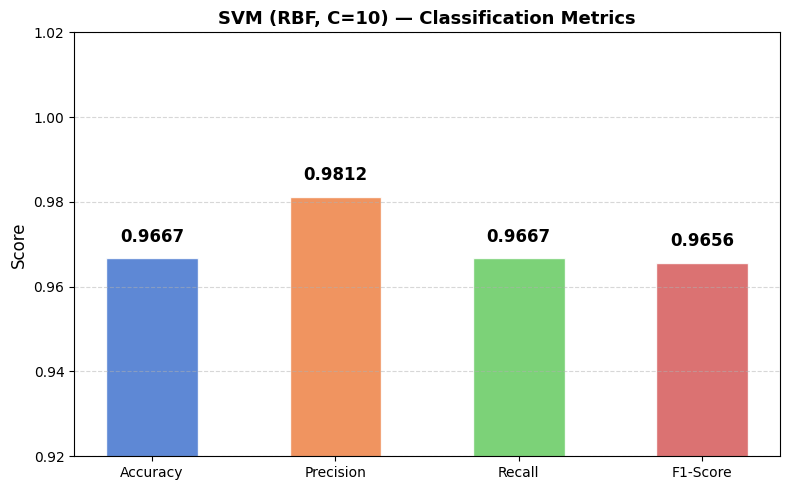

✅ Saved: svm_metrics.png


In [10]:
metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [acc, prec, rec, f1]
colors = ["#4878D0", "#EE854A", "#6ACC65", "#D65F5F"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metric_names, metric_values, color=colors, alpha=0.88,
              edgecolor="white", width=0.5)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0.92, 1.02)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("SVM (RBF, C=10) — Classification Metrics", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("../outputs/results/svm_metrics.png", dpi=150)
plt.show()
print("✅ Saved: svm_metrics.png")


### 9.3 — Cross-Validation per Fold

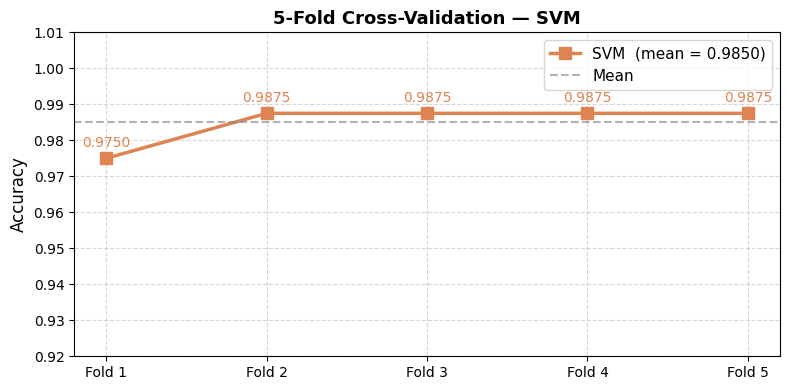

✅ Saved: svm_cross_validation.png


In [11]:
folds = [f"Fold {i+1}" for i in range(5)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(folds, cv_scores, "s-", color="#DD8452", linewidth=2.5,
        markersize=9, label=f"SVM  (mean = {cv_scores.mean():.4f})")
ax.axhline(cv_scores.mean(), color="gray", linestyle="--", alpha=0.6, label="Mean")

for i, s in enumerate(cv_scores):
    ax.annotate(f"{s:.4f}", (folds[i], s),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=10, color="#DD8452")

ax.set_ylim(0.92, 1.01)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("5-Fold Cross-Validation — SVM", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("../outputs/results/svm_cross_validation.png", dpi=150)
plt.show()
print("✅ Saved: svm_cross_validation.png")


## 10. Save Trained Model

بنحفظ الـ SVM model + الـ LabelEncoder عشان الـ **Attendance module** يقدر يلودهم ويعمل inference على صور جديدة.


In [12]:
MODELS_DIR = "../outputs/models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, "svm_classifier.pkl")

with open(model_path, "wb") as f:
    pickle.dump({"model": svm, "label_encoder": le}, f)

print(f"✅ Model saved at: {model_path}")
print(f"   Content: SVM model + LabelEncoder")


✅ Model saved at: ../outputs/models\svm_classifier.pkl
   Content: SVM model + LabelEncoder


## 11. Results Summary

In [13]:
print("=" * 45)
print("       SVM — Final Results Summary")
print("=" * 45)
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print(f"  CV (5-fold)    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 45)
print()
print("  Model : SVM (RBF kernel, C=10, gamma=scale)")
print("  Input : FaceNet-512 L2-normalized embeddings")
print("  Train : 280 samples (70%) | Test: 120 samples (30%)")
print("  Saved : ../outputs/models/svm_classifier.pkl")


       SVM — Final Results Summary
  Accuracy       : 0.9667  (96.67%)
  Precision      : 0.9812
  Recall         : 0.9667
  F1-Score       : 0.9656
  CV (5-fold)    : 0.9850 ± 0.0050

  Model : SVM (RBF kernel, C=10, gamma=scale)
  Input : FaceNet-512 L2-normalized embeddings
  Train : 280 samples (70%) | Test: 120 samples (30%)
  Saved : ../outputs/models/svm_classifier.pkl


## 12. Conclusion

### ما اتعمل في الـ Module ده
1. حملنا **FaceNet-512 embeddings** (40 subject × 10 images = 400 sample) من الـ database.
2. عملنا **L2 normalization** للـ embeddings.
3. قسمنا الداتا **70/30** مع stratification.
4. درّبنا **SVM (RBF, C=10)** وقيّمناه:

| Metric    | Value  |
|-----------|--------|
| Accuracy  | **96.67%** |
| Precision | **98.12%** |
| Recall    | **96.67%** |
| F1-Score  | **96.56%** |
| CV 5-fold | **98.50% ± 0.50%** |

### ليه SVM؟
- **High-dimensional data**: الـ SVM بيتعامل بكفاءة مع الـ 512-D embeddings.
- **Max-margin classifier**: بيحقق أفضل separation بين الـ classes.
- **Stability**: variance منخفض جداً عبر الـ 5 folds (± 0.0050).

### Next Step → **Module 6: Attendance**
تحميل الـ `svm_classifier.pkl`، inference على صورة جديدة، تحديد هوية الطالب، وتسجيل الحضور في `attendance_log.csv`.
